# Análisis Exploratorio de Datos (EDA)

Vamos a analizar el dataset limpio para comprender la distribución de las variables, identificar relaciones entre ellas y evaluar aspectos que puedan influir en el entrenamiento del modelo de clasificación.

El análisis se realiza sobre la versión limpia del conjunto de datos (`data/clean-data/pacientes_clean.csv`), obtenida tras el proceso de aseguramiento de calidad.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [32]:
df = pd.read_csv("../data/clean-data/pacientes_clean.csv")

print(df.shape)

df.head()

(500, 10)


,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal


## Distribución de variables numéricas

Se analiza la distribución de las variables continuas para identificar posibles sesgos, valores atípicos o concentraciones particulares.

In [ ]:
# Variables numéricas
numericas = [
    "edad_paciente",
    "peso_kg",
    "altura_cm",
    "frecuencia_cardiaca_media_bpm",
]

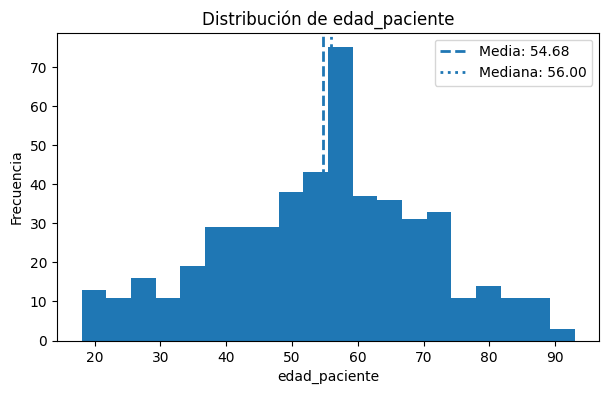

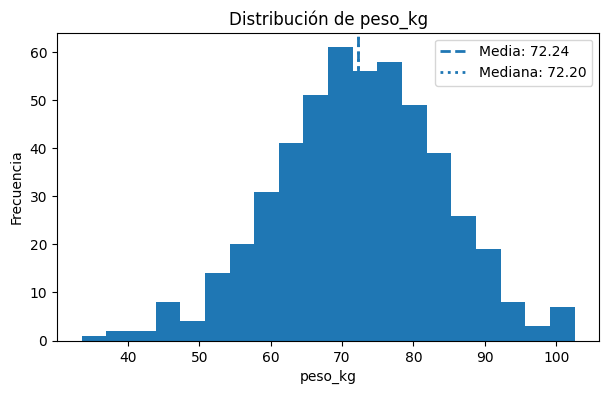

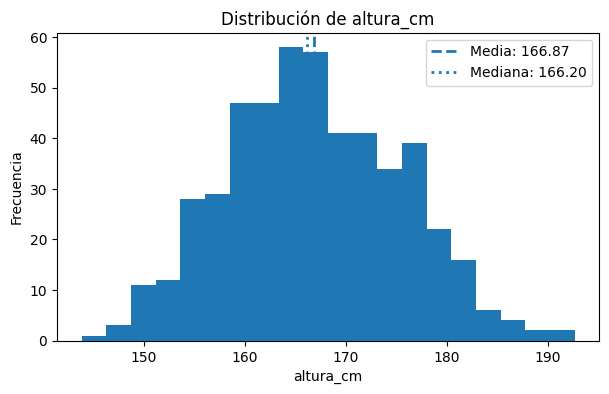

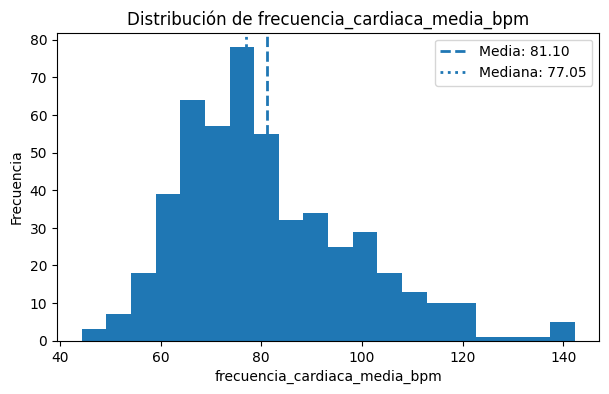

In [47]:
for col in numericas:

    media = df[col].mean()
    mediana = df[col].median()

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=20)

    plt.axvline(
        media,
        linestyle="--",
        linewidth=2,
        label=f"Media: {media:.2f}"
    )

    plt.axvline(
        mediana,
        linestyle=":",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}"
    )

    plt.title(f"Distribución de {col}")

    plt.xlabel(col)

    plt.ylabel("Frecuencia")

    plt.legend()

    plt.show()

Las variables numéricas **edad del paciente**, **peso** y **altura** presentan distribuciones coherentes con una población adulta. En los tres casos, la media y la mediana son muy cercanas, lo que sugiere distribuciones aproximadamente simétricas y sin un sesgo pronunciado.

Tras el proceso de limpieza no se observan valores fisiológicamente imposibles ni anomalías que justifiquen nuevas acciones de depuración. Los valores ubicados en los extremos de las distribuciones permanecen dentro de rangos plausibles y reflejan la variabilidad esperada de la población.

En conjunto, estas variables muestran una calidad adecuada para ser utilizadas como características de entrada en el entrenamiento del modelo de clasificación.

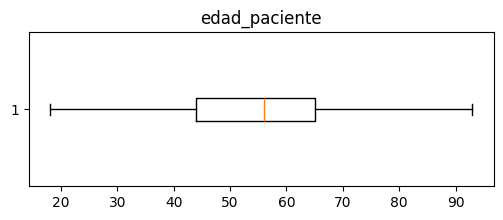

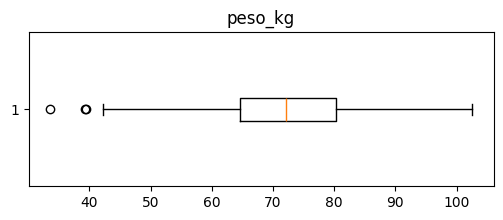

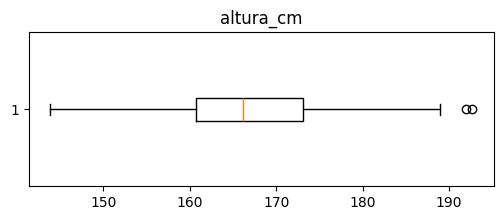

In [ ]:
# Boxplots para las variables numéricas
for col in numericas:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

Los posibles valores atípicos observados se consideran plausibles desde el punto de vista clínico y no fueron eliminados, como la frencuencia cardiaca donde vemos que los picos se extienden hacia los valores más altos.

## Variables categóricas

In [36]:
categoricas = [
    "sexo",
    "etiqueta"
]

In [37]:
for col in categoricas:

    print(col)

    print(df[col].value_counts())

    print()

sexo
sexo
M    259
F    241
Name: count, dtype: int64

etiqueta
etiqueta
Normal     300
Anormal    200
Name: count, dtype: int64



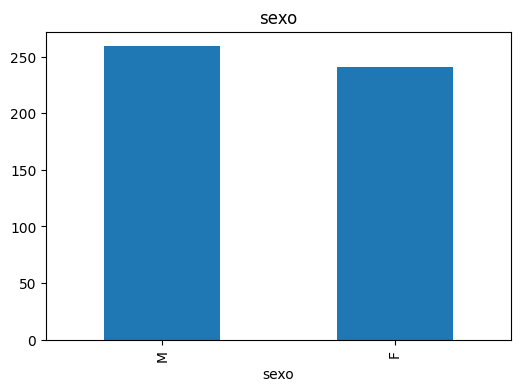

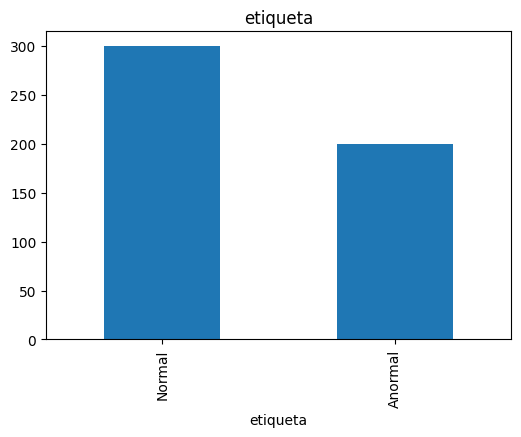

In [38]:
for col in categoricas:

    plt.figure(figsize=(6,4))

    df[col].value_counts().plot(kind="bar")

    plt.title(col)

    plt.show()

In [39]:
df["etiqueta"].value_counts(normalize=True)

etiqueta
Normal     0.6
Anormal    0.4
Name: proportion, dtype: float64

La variable objetivo presenta dos clases:

- **Normal (60%)**: pacientes cuyo ECG no presenta hallazgos patológicos relevantes.
- **Anormal (40%)**: pacientes cuyo ECG presenta al menos una alteración identificable.

La distribución de clases es relativamente equilibrada (60/40), por lo que no se considera un problema severo de desbalance.

No obstante, debido a que se trata de un problema de clasificación en un contexto clínico, la evaluación del modelo no se basará únicamente en la métrica de Accuracy.

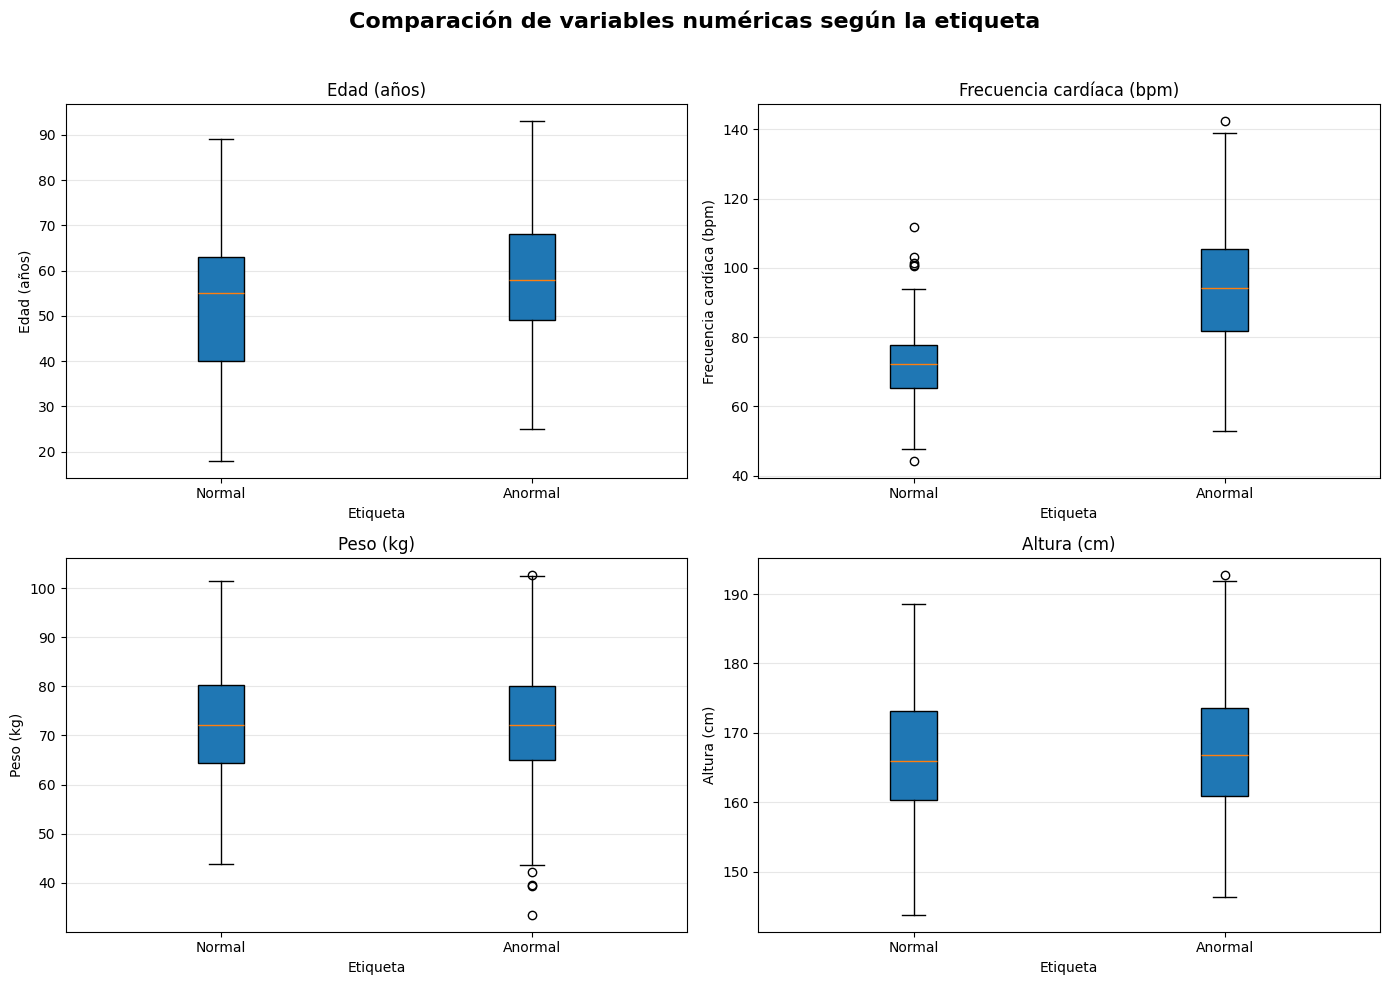

In [30]:
import matplotlib.pyplot as plt

variables = [
    ("edad_paciente", "Edad (años)"),
    ("frecuencia_cardiaca_media_bpm", "Frecuencia cardíaca (bpm)"),
    ("peso_kg", "Peso (kg)"),
    ("altura_cm", "Altura (cm)")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, etiqueta_x) in zip(axes.ravel(), variables):

    datos = [
        df.loc[df["etiqueta"] == "Normal", col],
        df.loc[df["etiqueta"] == "Anormal", col]
    ]

    ax.boxplot(
        datos,
        tick_labels=["Normal", "Anormal"],
        patch_artist=True
    )

    ax.set_title(etiqueta_x)
    ax.set_xlabel("Etiqueta")
    ax.set_ylabel(etiqueta_x)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Comparación de variables numéricas según la etiqueta",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

Los diagramas de caja muestran que **edad**, **peso** y **altura** presentan medianas y rangos intercuartílicos muy similares entre las clases Normal y Anormal, lo que sugiere que estas variables, de forma individual, poseen una capacidad limitada para discriminar entre ambas categorías.

En contraste, la frecuencia cardíaca media evidencia una diferencia más marcada entre las clases, observándose una tendencia a valores superiores en los pacientes con ECG Anormal. Este comportamiento indica que dicha variable podría aportar un mayor poder discriminativo durante el entrenamiento del modelo.

En conjunto, el análisis sugiere que la clasificación no depende de una única característica clínica, sino de la combinación de múltiples variables, aspecto que será aprovechado durante la etapa de modelado.

## Correlación entre variables numéricas

Finalmente, se analiza la correlación entre las variables numéricas mediante el coeficiente de Pearson. Este análisis permite identificar relaciones lineales entre las características y evaluar si existen variables altamente correlacionadas que puedan aportar información redundante al modelo.

In [ ]:
# LLamamos al diccionario con las variables numericas para calcular la matriz de correlación
corr = df[numericas].corr()
corr


,edad_paciente,peso_kg,altura_cm,frecuencia_cardiaca_media_bpm
edad_paciente,1.000000,0.045244,0.055452,0.177839
peso_kg,0.045244,1.000000,0.727488,0.011389
altura_cm,0.055452,0.727488,1.000000,0.014386
frecuencia_cardiaca_media_bpm,0.177839,0.011389,0.014386,1.000000


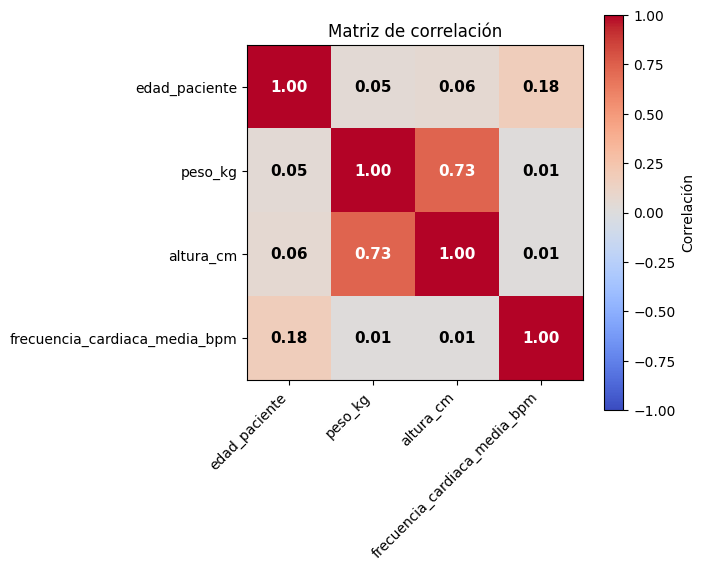

In [ ]:
import matplotlib.pyplot as plt

corr = df[numericas].corr()

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):

        valor = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white" if abs(valor) >= 0.5 else "black"
        )

plt.colorbar(im, label="Correlación")

plt.title("Matriz de correlación")

plt.tight_layout()

plt.show()

La matriz de correlación muestra que, en general, las variables numéricas presentan correlaciones bajas, lo que indica que cada una aporta información diferente al conjunto de datos.

La relación más fuerte se observa entre peso y altura (*r = 0.73*), una correlación positiva moderadamente alta y esperable desde el punto de vista fisiológico, ya que las personas con mayor estatura tienden a presentar un mayor peso. No obstante, este valor no es lo suficientemente alto como para considerarse un problema de multicolinealidad.

La edad presenta correlaciones muy bajas con el peso (*r = 0.05*) y la altura (*r = 0.06*), así como una relación débil con la frecuencia cardíaca media (*r = 0.18*). Esto sugiere que la edad aporta información relativamente independiente del resto de variables.

Por su parte, la frecuencia cardíaca media muestra una correlación prácticamente nula con el peso y la altura (*r = 0.01* en ambos casos), indicando que su comportamiento no depende linealmente de estas características. Este resultado complementa el análisis previo, donde la frecuencia cardíaca evidenció una mejor capacidad para diferenciar pacientes con ECG normal y anormal.


-----------------------------

# General

Con este EDA validamos que el conjunto de datos limpio presenta una estructura consistente y adecuada para el desarrollo del modelo de clasificación.

Las variables numéricas muestran distribuciones plausibles para una población adulta y no se identifican anomalías adicionales tras el proceso de limpieza. Asimismo, la variable objetivo presenta una distribución suficientemente equilibrada para entrenar un modelo baseline sin aplicar técnicas específicas de balanceo.

Finalmente, el análisis sugiere que la frecuencia cardíaca media podría desempeñar un papel importante en la clasificación, mientras que el resto de variables aportarían información complementaria. Con estos resultados, el conjunto de datos se considera listo para la etapa de preparación y entrenamiento del modelo.